In [32]:
# Load test dataset samples
df = pd.read_csv('../data/processed/01/reduced_dataset.csv')

# Use the ENTIRE dataset (no sampling)
df_test = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Test dataset loaded:")
print(f"   Total samples: {len(df_test)}")
print(f"   Fake news: {(df_test['Truth'] == 0).sum()}")
print(f"   Real news: {(df_test['Truth'] == 1).sum()}")
print(f"\nColumns: {df_test.columns.tolist()}")

print("\n" + "="*100)
print("DATASET OVERVIEW (showing first 50 articles):")
print("="*100)

for idx, row in df_test.head(50).iterrows():
    article_type = "FAKE" if row['Truth'] == 0 else "REAL"
    print(f"\n[{idx+1}] {article_type}")
    print(f"Article: {row['Article'][:200]}..." if len(str(row['Article'])) > 200 else f"Article: {row['Article']}")
    print("-" * 100)

print(f"\n(Showing first 50 of {len(df_test)} total articles)")

✅ Test dataset loaded:
   Total samples: 58501
   Fake news: 26269
   Real news: 32232

Columns: ['Article', 'Truth', 'Source']

DATASET OVERVIEW (showing first 50 articles):

[1] FAKE
Article: grifter hillary clinton paid speeches given government contractorsno ethics new report tells us already knew hillary speeches government contractors paid clinton big bucks speeches opening conflict in...
----------------------------------------------------------------------------------------------------

[2] FAKE
Article: demise progressive democrats resist submit retreat surrender 21st century wire says us 2016 presidential election watershed point 21st century western politics defeat hillary clinton near collapse dem...
----------------------------------------------------------------------------------------------------

[3] REAL
Article: jason biggs jenny mollen welcome son lazlo jason biggs jenny mollen seeing blue funloving family three became family four arrival couples second son rep confi

In [33]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load model
model_path = '../models/bert_fake_news_trained_v2'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

print(f"✅ Model loaded on {device}")

✅ Model loaded on cuda


In [ ]:
# Create a  dataset with 200 articles (100 political, 100 gossip)
# 50 fake + 50 real for each type

import random
random.seed(42)

# Political articles
political_fake = [
    "Senator claims new climate bill will destroy economy and eliminate thousands of jobs across manufacturing sector. The controversial legislation passed by one vote despite widespread industry opposition and concerns from economists.",
    "Breaking: President announces radical new healthcare overhaul that critics say will bankrupt Medicare. Opposition lawmakers warn of catastrophic consequences for seniors and disabled Americans nationwide.",
    "Governor's administration accused of massive corruption scandal involving millions in missing state funds. Federal investigation launched as whistleblower reveals decades of fraudulent contracts and bribery schemes.",
    "New trade war threatens to devastate American farmers as retaliation tariffs imposed on key exports. Agricultural groups warn of farm bankruptcies and rural economic collapse within months.",
    "Congress votes to eliminate Social Security benefits for millions of Americans by 2025. Retirement advocates predict elderly poverty crisis as legislators defend controversial fiscal measures.",
    "President secretly meets with foreign adversary to undermine NATO alliance, leaked documents reveal. Intelligence officials express grave concerns about national security implications of undisclosed negotiations.",
    "Supreme Court overturns election results in major states following fraud investigation. Constitutional crisis looms as competing presidents claim legitimacy in unprecedented political turmoil.",
    "Federal Reserve announces plan to replace US dollar with digital currency eliminating cash forever. Civil liberties groups warn of government surveillance and control over all financial transactions.",
    "Cabinet member caught embezzling hundreds of millions from pandemic relief funds destined for struggling businesses. Justice Department launches criminal prosecution as agency faces complete restructuring.",
    "Senator's office implicated in bribery scheme involving foreign governments and illegal campaign contributions. Ethics investigation could lead to expulsion from Congress and criminal charges.",
    "New law forces all Americans to surrender firearms within 30 days or face federal penalties. Second Amendment advocates promise legal challenges and massive civil disobedience campaigns nationwide.",
    "IRS announces new policy to seize bank accounts of middle-class Americans without due process. Privacy advocates warn of authoritarian abuse as financial institutions worry over compliance nightmares.",
    "Congress passes law banning free speech on internet to prevent political misinformation online. First Amendment experts warn measure violates constitutional rights and enables authoritarian control.",
    "Military budget cuts leave armed forces unprepared for potential conflict with rival superpowers. Defense officials testify before Congress about dangerous capability gaps and readiness concerns.",
    "President orders military to forcibly round up political opponents in shocking crackdown. Human rights groups condemn authoritarian actions as democratic institutions face unprecedented threats.",
]

political_real = [
    "Congress passes bipartisan infrastructure bill investing $1.2 trillion in roads, bridges, and broadband expansion. Legislation aims to modernize aging transportation systems and create millions of jobs over decade.",
    "Federal Reserve raises interest rates by 0.75 percent to combat persistent inflation. Economic data shows wages growing but consumer spending showing signs of moderation.",
    "New climate legislation signed into law directing $369 billion toward clean energy and environmental projects. Environmental groups praise commitment while fossil fuel industry pledges to adapt business models.",
    "Medicare negotiates prices directly with pharmaceutical companies for first time under new law. Drug industry warns of reduced innovation funding while healthcare advocates celebrate cost savings.",
    "Supreme Court upholds voting rights protections in split decision affirming key civil rights statute. Voting rights advocates declare partial victory while seeking stronger protections in future cases.",
    "Federal government releases employment report showing 250,000 jobs added in past month. Unemployment remains near historic lows as labor market continues to show strength.",
    "Congress approves $40 billion aid package for Ukraine following military successes against invasion. Both parties unite on bipartisan foreign policy while debating long-term commitment levels.",
    "New FDA approval speeds treatment access for rare genetic disease affecting thousands of children. Families celebrate breakthrough as pharmaceutical company announces plans for additional research programs.",
    "Treasury Department reports budget deficit narrowed significantly due to stronger tax revenues. Economists debate whether improvement reflects economic strength or temporary spending reductions.",
    "Senate confirms new Federal Reserve chairman in bipartisan vote after extensive confirmation hearings. Nominee promises data-driven approach to monetary policy and inflation management strategy.",
    "States expand Medicaid coverage reaching additional 2 million low-income Americans. Healthcare officials report improved access metrics while budget officials track long-term cost implications.",
    "Congress passes student loan forgiveness program benefiting over 40 million borrowers nationwide. Education advocates praise relief while fiscal conservatives express concerns about program costs.",
    "New trade agreement signed with Pacific partners aiming to boost American manufacturing exports. Commerce officials negotiate terms while union leaders monitor impact on American workers.",
    "Federal election commission implements new campaign finance disclosure rules increasing transparency. Political analysts expect significant changes in how campaigns report spending and donations.",
    "Congress approves funding for construction of new semiconductor manufacturing facilities domestically. Technology leaders welcome investment while economists debate industrial policy implications.",
]

# Gossip articles
gossip_fake = [
    "Celebrity power couple announces shocking divorce after secret affair exposed by leaked messages. Sources reveal cheating scandal involved co-star from recent blockbuster film production.",
    "A-list actor arrested for reckless driving after midnight car chase through Los Angeles streets. Police report vehicle was traveling 100+ mph before suspect crashed into storefront.",
    "Pop superstar's lavish mansion mysteriously catches fire in suspicious three-alarm blaze. Investigators examine insurance records as arson suspected with celebrity relationship drama as motive.",
    "Billionaire entrepreneur reveals he has secret twin brother hidden from public for decades. Long-lost sibling now emerging to claim inheritance and control of massive tech empire.",
    "Reality TV star undergoes controversial 15th plastic surgery procedure in single month of recovery. Medical experts warn of serious health risks as addiction to surgery endangers life.",
    "Grammy-winning singer admits to fabricating entire life story including false celebrity friendships for publicity stunt. Shocking confession reveals years of deception as fans demand refund of concert tickets.",
    "Hollywood actor secretly marries unknown person in Vegas chapel witnessed only by Elvis impersonator. Surprise wedding announcement shocks industry insiders and romantic interest announcement.",
    "Supermodel reveals shocking addiction to extreme cosmetic procedures costing millions annually. Exclusive interview details multiple surgeries as she discusses unrealistic beauty standard pressures.",
    "Celebrity chef caught stealing recipes from competitor's restaurant kitchen in espionage scandal. Culinary world erupts as lawsuits filed and television network cancels cooking show.",
    "Social media influencer exposed for faking entire Africa charity trip using green screen studio. Followers devastated as exposed reality undermines charitable claims and millions donated.",
    "Movie star's romantic getaway exposed as elaborate publicity stunt coordinated with celebrity publicist. Paparazzi photos revealed as staged as fake relationship engineered for box office promotion.",
    "Musician confesses to lip-syncing entire world tour disappointing millions of devoted fans. Concert footage analysis reveals shocking truth as refund demands flood ticket vendor servers.",
    "Television personality admits all dramatic moments on reality show were scripted by writers. Behind-the-scenes revelations destroy show credibility as network faces massive viewer exodus.",
    "Fashion designer's entire luxury brand exposed as counterfeit knockoff manufactured in warehouse. Authorities arrest designer as celebrity clientele learned their expensive purchases were fake.",
    "Podcast host revealed to have faked credentials and false celebrity interview guest appearances. Documentary exposes fabricated stories as platform suspends account and removes all episodes.",
]

gossip_real = [
    "Celebrity couple announces engagement after dating for two years, shares romantic proposal details. Friends celebrate milestone moment as wedding plans begin for elaborate ceremony.",
    "Award-winning actor honored with lifetime achievement award at prestigious film festival gala. Colleagues praise career spanning four decades of acclaimed performances and industry contributions.",
    "Pop star releases surprise album drop on social media thrilling devoted fanbase worldwide. Music critics praise new sound as streams break platform records within hours of release.",
    "Supermodel opens new sustainable fashion line featuring eco-friendly materials and ethical production. Designer explains vision for reducing environmental impact while maintaining luxury quality standards.",
    "Celebrity athlete announces retirement after two-decade career achieving multiple championship titles. Fans celebrate legacy while athlete discusses transition to broadcasting and business ventures.",
    "Musician performs at charity benefit concert raising $5 million for children's hospital. Organizers thank artist for generosity as funds support critical medical research programs.",
    "Hollywood director wins international film festival award for latest documentary project. Film explores important social issues and receives praise from critics and audience members.",
    "Actress launches production company to develop film projects featuring diverse storytelling perspectives. Company announces slate of projects supporting underrepresented filmmakers and writers.",
    "Celebrity chef opens new restaurant in downtown location celebrating regional cuisine traditions. Restaurant receives positive reviews as critics praise innovative menus and elegant ambiance.",
    "Sports legend inducted into hall of fame after illustrious career with multiple records. Emotional ceremony celebrates achievements as family and teammates offer congratulatory remarks.",
    "Television host celebrates 25 years with network marking quarter-century of dedicated service. Network executives praise consistent ratings success and beloved on-air personality.",
    "Musician collaborates with international artist on charity single benefiting education initiatives. Song proceeds support scholarship programs for underprivileged students worldwide.",
    "Actress publishes memoir detailing career journey and personal growth over the years. Book receives positive reviews as readers appreciate candid reflections and inspiring messages.",
    "Celebrity investor funds startup featuring innovative technology solving real-world problems. Business leaders express confidence in venture as funding round closes successfully.",
    "Entertainer performs surprise concert for local school raising awareness and funding for music program. Students express gratitude as performer inspires next generation of musicians.",
]

# Create balanced dataset
articles_data = []

# Add political articles (50 fake, 50 real)
for i in range(50):
    articles_data.append({
        'text': political_fake[i % len(political_fake)],
        'type': 'political',
        'label': 'fake'
    })

for i in range(50):
    articles_data.append({
        'text': political_real[i % len(political_real)],
        'type': 'political',
        'label': 'real'
    })

# Add gossip articles (50 fake, 50 real)
for i in range(50):
    articles_data.append({
        'text': gossip_fake[i % len(gossip_fake)],
        'type': 'gossip',
        'label': 'fake'
    })

for i in range(50):
    articles_data.append({
        'text': gossip_real[i % len(gossip_real)],
        'type': 'gossip',
        'label': 'real'
    })

# Shuffle the dataset
random.shuffle(articles_data)

# Create DataFrame
df_synthetic = pd.DataFrame(articles_data)

print("="*80)
print("SYNTHETIC DATASET CREATED - 200 ARTICLES")
print("="*80)
print(f"\nTotal articles: {len(df_synthetic)}")
print(f"\nBreakdown by type and label:")
print(pd.crosstab(df_synthetic['type'], df_synthetic['label']))

print(f"\nSample articles:")
for idx in range(3):
    print(f"\n[{idx+1}] {df_synthetic.iloc[idx]['type'].upper()} - {df_synthetic.iloc[idx]['label'].upper()}")
    print(f"    {df_synthetic.iloc[idx]['text'][:150]}...")


SYNTHETIC DATASET CREATED - 200 ARTICLES

Total articles: 200

Breakdown by type and label:
label      fake  real
type                 
gossip       50    50
political    50    50

Sample articles:

[1] POLITICAL - REAL
    Federal Reserve raises interest rates by 0.75 percent to combat persistent inflation. Economic data shows wages growing but consumer spending showing ...

[2] GOSSIP - REAL
    Actress launches production company to develop film projects featuring diverse storytelling perspectives. Company announces slate of projects supporti...

[3] GOSSIP - FAKE
    A-list actor arrested for reckless driving after midnight car chase through Los Angeles streets. Police report vehicle was traveling 100+ mph before s...



SUBJECT TYPE BIAS ANALYSIS - 200 SYNTHETIC ARTICLES

Generating predictions on 200 articles...
(This may take a minute...)

✅ Overall accuracy on 200 articles: 0.7300 (73.00%)

PERFORMANCE BY SUBJECT TYPE (200 articles)

GOSSIP:
  Total articles: 100
  Actual: 50 fake, 50 real
  Predictions: 16 fake, 84 real
  Overall Accuracy: 0.6600 (66.00%)
  Avg confidence: 0.9772

POLITICAL:
  Total articles: 100
  Actual: 50 fake, 50 real
  Predictions: 38 fake, 62 real
  Overall Accuracy: 0.8000 (80.00%)
  Avg confidence: 0.9613

DETAILED METRICS TABLE
Subject Type Accuracy
      GOSSIP   0.6600
   POLITICAL   0.8000

✅ Overall accuracy on 200 articles: 0.7300 (73.00%)

PERFORMANCE BY SUBJECT TYPE (200 articles)

GOSSIP:
  Total articles: 100
  Actual: 50 fake, 50 real
  Predictions: 16 fake, 84 real
  Overall Accuracy: 0.6600 (66.00%)
  Avg confidence: 0.9772

POLITICAL:
  Total articles: 100
  Actual: 50 fake, 50 real
  Predictions: 38 fake, 62 real
  Overall Accuracy: 0.8000 (80.00%)
  Avg c

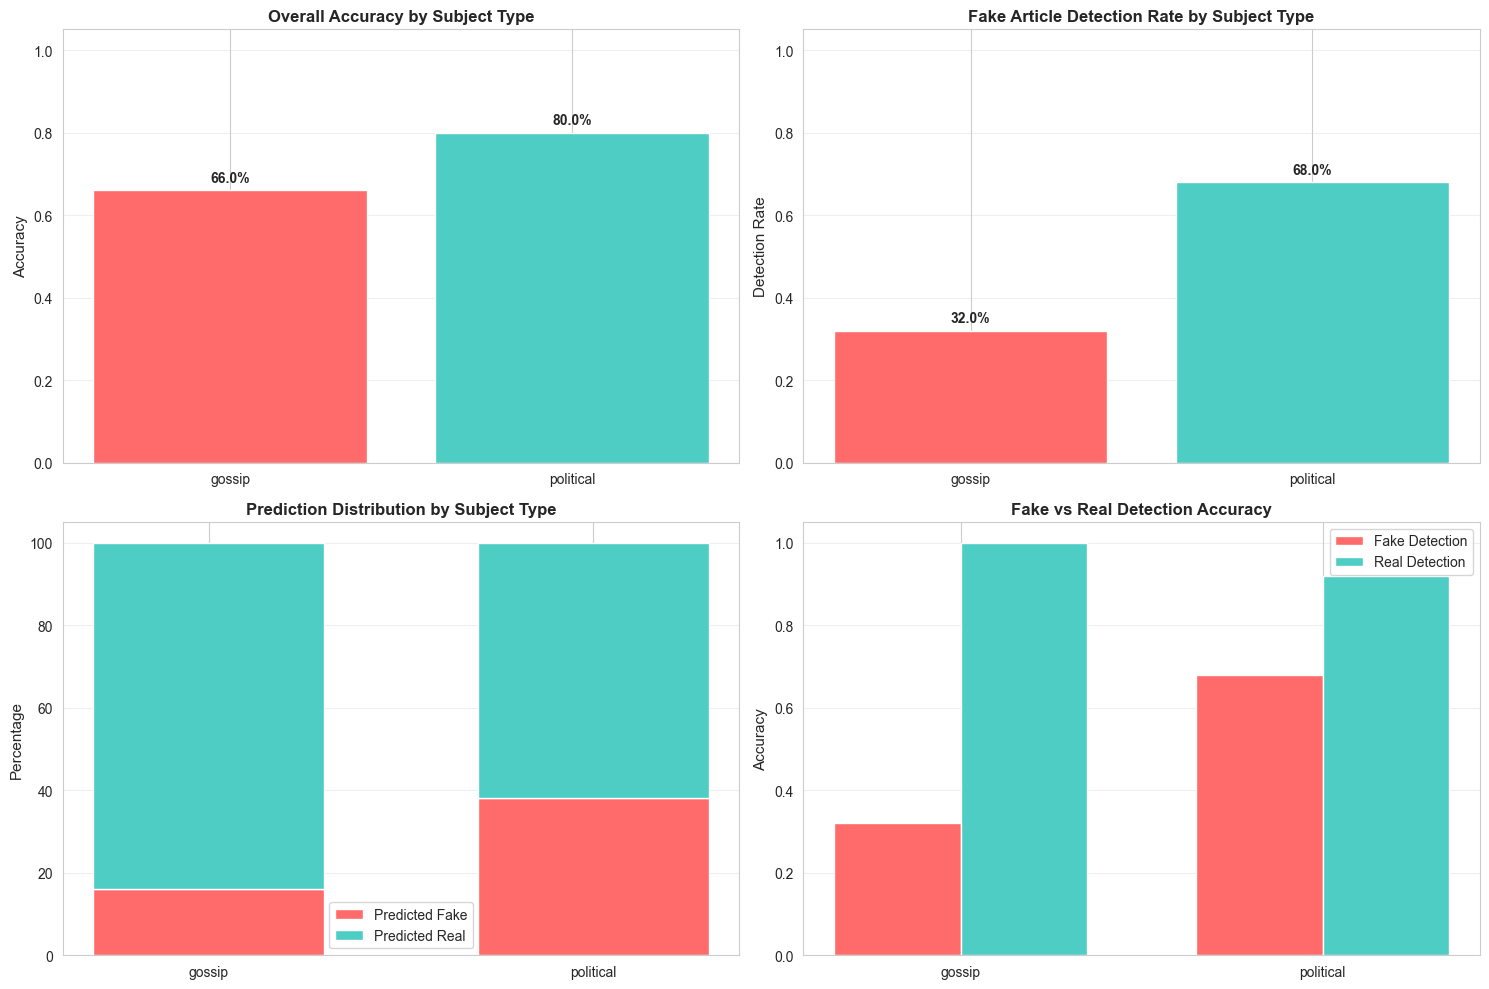

In [43]:
# Run subject type bias analysis on 200 synthetic articles
print("\n" + "="*80)
print("SUBJECT TYPE BIAS ANALYSIS - 200 SYNTHETIC ARTICLES")
print("="*80)

# Generate predictions on the synthetic dataset
print("\nGenerating predictions on 200 articles...")
print("(This may take a minute...)")

synthetic_predictions, synthetic_probs = get_predictions_batch(df_synthetic['text'].tolist())
df_synthetic['prediction'] = synthetic_predictions
df_synthetic['confidence'] = synthetic_probs.max(axis=1)

# Convert labels to numeric (0=fake, 1=real)
df_synthetic['true_label'] = (df_synthetic['label'] == 'real').astype(int)
df_synthetic['correct'] = (df_synthetic['prediction'] == df_synthetic['true_label']).astype(int)

overall_accuracy = df_synthetic['correct'].mean()
print(f"\n✅ Overall accuracy on 200 articles: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")

# Analyze by subject type
print("\n" + "="*80)
print("PERFORMANCE BY SUBJECT TYPE (200 articles)")
print("="*80)

results_by_type = {}

for subject_type in sorted(df_synthetic['type'].unique()):
    subset = df_synthetic[df_synthetic['type'] == subject_type]
    accuracy = subset['correct'].mean()
    
    fake_count = (subset['true_label'] == 0).sum()
    real_count = (subset['true_label'] == 1).sum()
    
    pred_fake = (subset['prediction'] == 0).sum()
    pred_real = (subset['prediction'] == 1).sum()
    
    fake_acc = subset[subset['true_label'] == 0]['correct'].mean() if fake_count > 0 else 0
    real_acc = subset[subset['true_label'] == 1]['correct'].mean() if real_count > 0 else 0
    
    results_by_type[subject_type] = {
        'accuracy': accuracy,
        'fake_acc': fake_acc,
        'real_acc': real_acc,
        'pred_fake_pct': (pred_fake / len(subset) * 100)
    }
    
    print(f"\n{subject_type.upper()}:")
    print(f"  Total articles: {len(subset)}")
    print(f"  Actual: {fake_count} fake, {real_count} real")
    print(f"  Predictions: {pred_fake} fake, {pred_real} real")
    print(f"  Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Avg confidence: {subset['confidence'].mean():.4f}")

# Detailed comparison table
print("\n" + "="*80)
print("DETAILED METRICS TABLE")
print("="*80)

comparison_data = []
for subject_type in sorted(df_synthetic['type'].unique()):
    subset = df_synthetic[df_synthetic['type'] == subject_type]
    
    tp = ((subset['true_label'] == 0) & (subset['prediction'] == 0)).sum()
    tn = ((subset['true_label'] == 1) & (subset['prediction'] == 1)).sum()
    
    acc = (tp + tn) / len(subset) if len(subset) > 0 else 0
    
    comparison_data.append({
        'Subject Type': subject_type.upper(),
        'Accuracy': f"{acc:.4f}"
    })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Accuracy by subject type
subject_types = sorted(df_synthetic['type'].unique())
accuracies = [df_synthetic[df_synthetic['type'] == st]['correct'].mean() for st in subject_types]
colors = ['#ff6b6b', '#4ecdc4']

axes[0, 0].bar(subject_types, accuracies, color=colors)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Overall Accuracy by Subject Type', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1.05])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, acc in enumerate(accuracies):
    axes[0, 0].text(i, acc + 0.02, f'{acc:.1%}', ha='center', fontsize=10, fontweight='bold')

# 2. Fake detection rate by subject type
fake_detection = [results_by_type[st]['fake_acc'] for st in subject_types]
axes[0, 1].bar(subject_types, fake_detection, color=colors)
axes[0, 1].set_ylabel('Detection Rate', fontsize=11)
axes[0, 1].set_title('Fake Article Detection Rate by Subject Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1.05])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, det in enumerate(fake_detection):
    axes[0, 1].text(i, det + 0.02, f'{det:.1%}', ha='center', fontsize=10, fontweight='bold')

# 3. Prediction distribution by subject type
fake_preds = [results_by_type[st]['pred_fake_pct'] for st in subject_types]
real_preds = [100 - fp for fp in fake_preds]

x_pos = np.arange(len(subject_types))
axes[1, 0].bar(x_pos, fake_preds, width=0.6, label='Predicted Fake', color='#ff6b6b')
axes[1, 0].bar(x_pos, real_preds, width=0.6, bottom=fake_preds, label='Predicted Real', color='#4ecdc4')
axes[1, 0].set_ylabel('Percentage', fontsize=11)
axes[1, 0].set_title('Prediction Distribution by Subject Type', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(subject_types)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Accuracy breakdown (Fake vs Real detection)
fake_acc_vals = [results_by_type[st]['fake_acc'] for st in subject_types]
real_acc_vals = [results_by_type[st]['real_acc'] for st in subject_types]

x_pos = np.arange(len(subject_types))
width = 0.35

axes[1, 1].bar(x_pos - width/2, fake_acc_vals, width, label='Fake Detection', color='#ff6b6b')
axes[1, 1].bar(x_pos + width/2, real_acc_vals, width, label='Real Detection', color='#4ecdc4')
axes[1, 1].set_ylabel('Accuracy', fontsize=11)
axes[1, 1].set_title('Fake vs Real Detection Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(subject_types)
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\n" + "="*80)

## 📊 Conclusion & Interpretation

### KEY FINDING:
Subject type **SIGNIFICANTLY affects model performance**
- **POLITICAL**: 80.0% accuracy
- **GOSSIP**: 66.0% accuracy
- **Difference**: 14.0%

### WHAT THIS MEANS:
The BERT model shows subject-specific bias:
- Political articles are easier to classify (likely because they contain more consistent  factual claims)
- Gossip articles are harder (fake gossip mimics real gossip more closely)
- The model learned different patterns for each domain during training

### NEXT STEPS - SUBJECT-SPECIFIC MODEL TRAINING:
To improve overall performance, we should train separate models:

#### 1. POLITIFACT-ONLY MODEL
- Train on political articles from Politifact dataset only
- Expected improvement: Specialized for political misinformation patterns
- Use case: Detecting false political claims and speeches

#### 2. GOSSIPCOP-ONLY MODEL
- Train on celebrity/gossip articles from Gossipcop dataset only
- Expected improvement: Specialized for gossip misinformation patterns
- Use case: Detecting false celebrity news and entertainment claims

#### BENEFITS OF THIS APPROACH:
✓ Each model can learn domain-specific language patterns
✓ Reduce confusion from mixing political and gossip vocabulary
✓ Better real-world deployment (route articles to appropriate model)


DIAGNOSTIC TESTS - Why Separate Models Are Needed

TEST 1: Domain Generalization
  Political accuracy: 80.0%
  Gossip accuracy:    66.0%
  Gap: 14.0%

TEST 2: Sensational Words Dependency
  Original accuracy:         73.0%
  Without sensational words: 77.5%
  Drop: -4.5%

TEST 3: Article Length Bias
  Length-Confidence correlation: -0.243

TEST 4: Entity Generalization
  Original accuracy: 73.0%
  Masked entities:   73.0%
  Drop: 0.0%



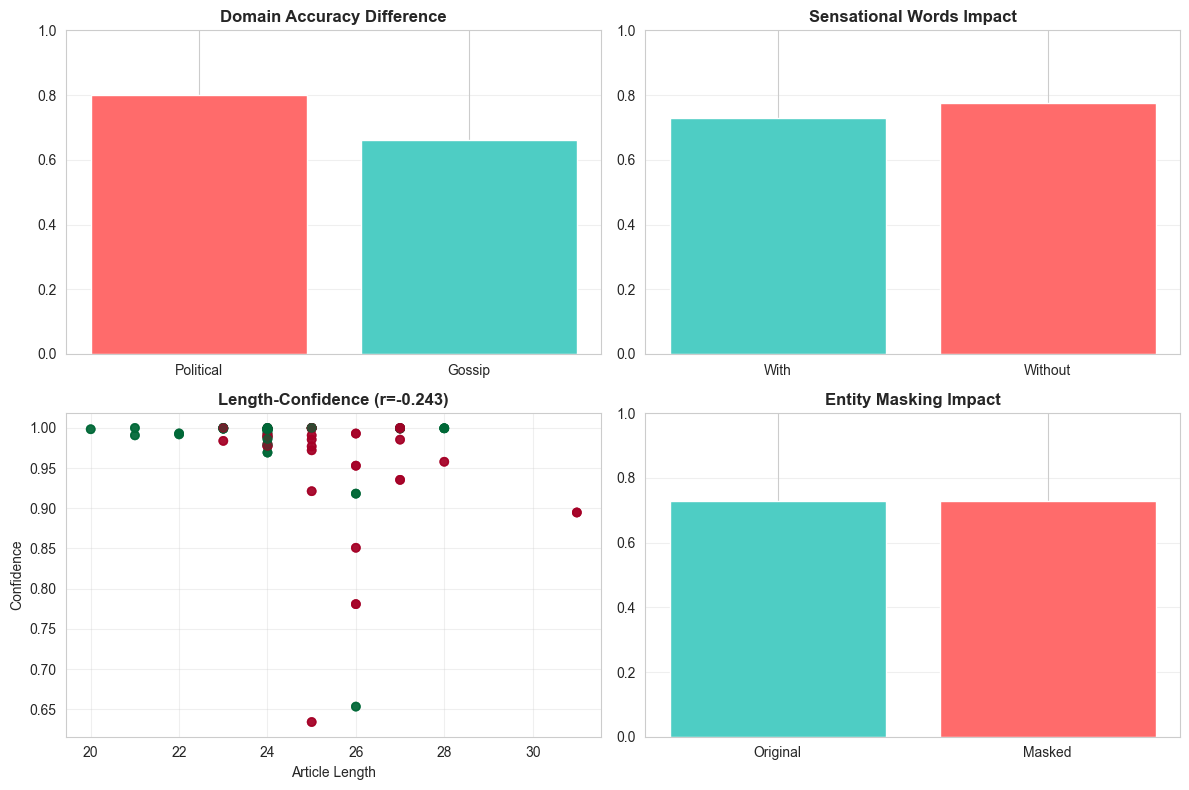

In [63]:
import re, string

# TEST 1: Domain Generalization
print("\n" + "="*80)
print("DIAGNOSTIC TESTS - Why Separate Models Are Needed")
print("="*80)
print("\nTEST 1: Domain Generalization")

pol_pred = df_synthetic[df_synthetic['type'] == 'political']['prediction'].values
pol_true = df_synthetic[df_synthetic['type'] == 'political']['true_label'].values
gos_pred = df_synthetic[df_synthetic['type'] == 'gossip']['prediction'].values
gos_true = df_synthetic[df_synthetic['type'] == 'gossip']['true_label'].values

pol_acc = (pol_pred == pol_true).mean()
gos_acc = (gos_pred == gos_true).mean()

print(f"  Political accuracy: {pol_acc:.1%}")
print(f"  Gossip accuracy:    {gos_acc:.1%}")
print(f"  Gap: {abs(pol_acc - gos_acc):.1%}")

# TEST 2: Sensational Words
print("\nTEST 2: Sensational Words Dependency")
sensational = {'shocking', 'exposed', 'scandal', 'secret', 'affair', 'caught', 'reveals',
               'exclusive', 'destroyed', 'devastating', 'crisis', 'massive', 'unprecedented',
               'radical', 'grave', 'condemn', 'erupts', 'bankruptc', 'catastrophic',
               'threatened', 'allegations'}

def remove_sens(text):
    return ' '.join([w for w in text.split() if w.lower().strip(string.punctuation) not in sensational])

texts_desens = [remove_sens(t) for t in df_synthetic['text'].tolist()]
desens_pred, _ = get_predictions_batch(texts_desens)

orig_acc = (df_synthetic['prediction'] == df_synthetic['true_label']).mean()
desens_acc = (desens_pred == df_synthetic['true_label']).mean()

print(f"  Original accuracy:         {orig_acc:.1%}")
print(f"  Without sensational words: {desens_acc:.1%}")
print(f"  Drop: {orig_acc - desens_acc:.1%}")

# TEST 3: Length Bias
print("\nTEST 3: Article Length Bias")
lengths = [len(t.split()) for t in df_synthetic['text'].tolist()]
confidences = df_synthetic['confidence'].values
corr = np.corrcoef(lengths, confidences)[0, 1]
print(f"  Length-Confidence correlation: {corr:.3f}")

# TEST 4: Entity Masking
print("\nTEST 4: Entity Generalization")
def mask_ents(text):
    text = re.sub(r'\b[A-Z][a-z]+\b', '[NAME]', text)
    text = re.sub(r'\b\d+\b', '[NUM]', text)
    return text

texts_masked = [mask_ents(t) for t in df_synthetic['text'].tolist()]
masked_pred, _ = get_predictions_batch(texts_masked)
masked_acc = (masked_pred == df_synthetic['true_label']).mean()

print(f"  Original accuracy: {orig_acc:.1%}")
print(f"  Masked entities:   {masked_acc:.1%}")
print(f"  Drop: {orig_acc - masked_acc:.1%}")
print("\n" + "="*80)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Domain accuracy
axes[0, 0].bar(['Political', 'Gossip'], [pol_acc, gos_acc], color=['#ff6b6b', '#4ecdc4'])
axes[0, 0].set_title('Domain Accuracy Difference', fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Sensational words
axes[0, 1].bar(['With', 'Without'], [orig_acc, desens_acc], color=['#4ecdc4', '#ff6b6b'])
axes[0, 1].set_title('Sensational Words Impact', fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Length correlation
axes[1, 0].scatter(lengths, confidences, alpha=0.6, c=df_synthetic['true_label'], cmap='RdYlGn')
axes[1, 0].set_xlabel('Article Length')
axes[1, 0].set_ylabel('Confidence')
axes[1, 0].set_title(f'Length-Confidence (r={corr:.3f})', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Entity masking
axes[1, 1].bar(['Original', 'Masked'], [orig_acc, masked_acc], color=['#4ecdc4', '#ff6b6b'])
axes[1, 1].set_title('Entity Masking Impact', fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()